# Exp1

   Age  %Fat
0   23   7.8
1   23   9.5
2   27  17.8
3   27  25.8
4   39  26.5
             Age       %Fat
count  18.000000  18.000000
mean   46.444444  28.777778
std    13.218624   9.256257
min    23.000000   7.800000
25%    39.500000  26.675000
50%    51.000000  30.700000
75%    56.750000  33.925000
max    61.000000  42.500000
Mode: 7.8
Outliers:    Age  %Fat
0   23   7.8
1   23   9.5


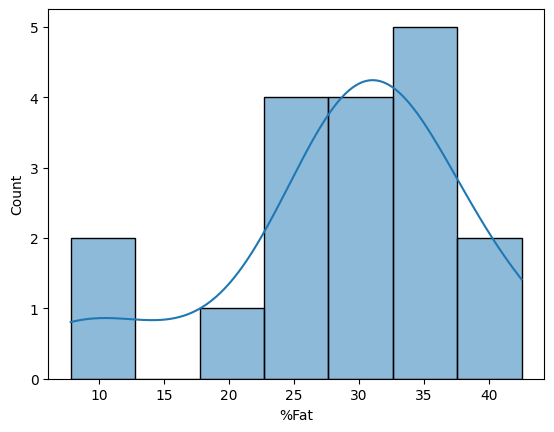

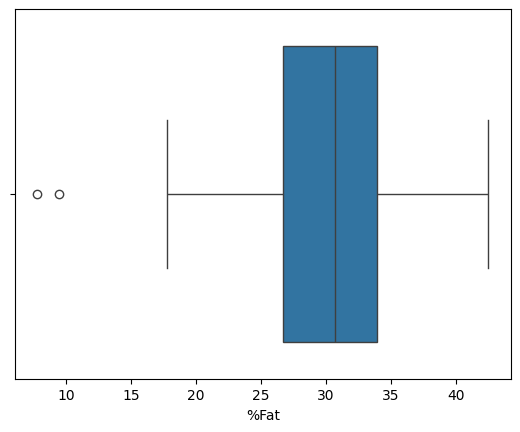

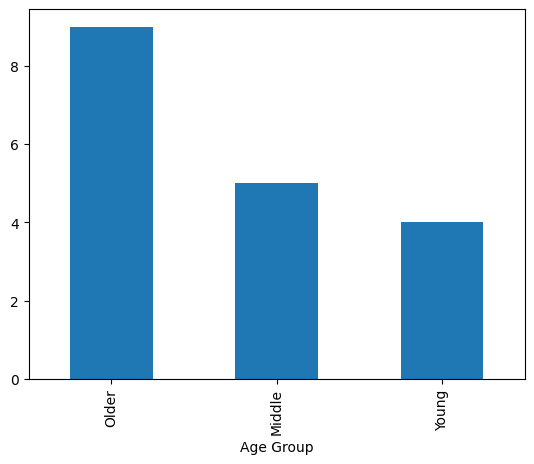

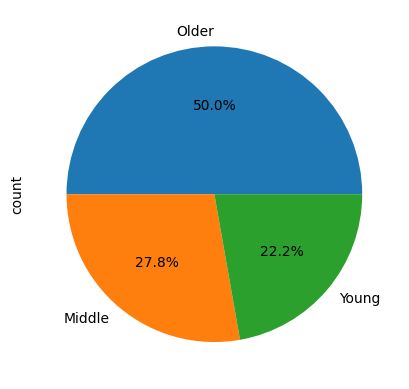

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.DataFrame(
    {
        'Age': [23, 23, 27, 27, 39, 41, 47, 49, 50, 52, 54, 54, 56, 57, 58, 58, 60, 61],
        '%Fat': [7.8, 9.5, 17.8, 25.8, 26.5, 27.2, 27.4, 28.8, 30.2, 31.2, 31.4, 32.9, 33.4, 34.1, 34.6, 35.7, 41.2, 42.5]
    }
)

print(df.head())
print(df.describe())
print("Mode:", df['%Fat'].mode()[0])
Q1 = df['%Fat'].quantile(0.25)
Q3 = df['%Fat'].quantile(0.75)
IQR = Q3 - Q1
print("Outliers:", df[(df['%Fat'] < (Q1 - 1.5 * IQR))
                    | (df['%Fat'] > (Q3 + 1.5 * IQR))])

df['Age Group'] = pd.cut(df['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle', 'Older'])

sns.histplot(df['%Fat'], kde=True)
plt.show()

sns.boxplot(x=df['%Fat'])
plt.show()

df['Age Group'].value_counts().plot(kind='bar')
plt.show()

df['Age Group'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()


# Exp2

   sepal_length  sepal_width  petal_length  petal_width variety
0           5.1          3.5           1.4          0.2  Setosa
1           4.9          3.0           1.4          0.2  Setosa
2           4.7          3.2           1.3          0.2  Setosa
3           4.6          3.1           1.5          0.2  Setosa
4           5.0          3.6           1.4          0.2  Setosa


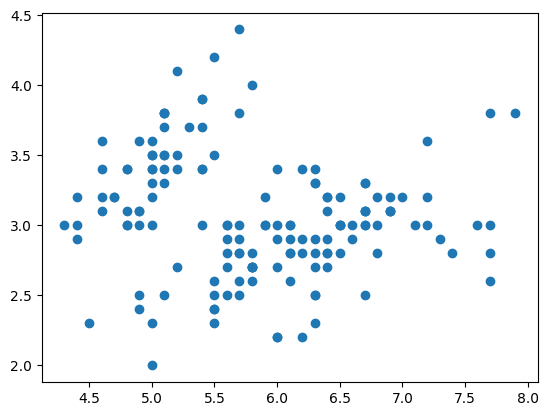

Pearson correlation coefficient:
 -0.11756978413300208
Covariance matrix:
 [[ 0.68569351 -0.042434  ]
 [-0.042434    0.18997942]]


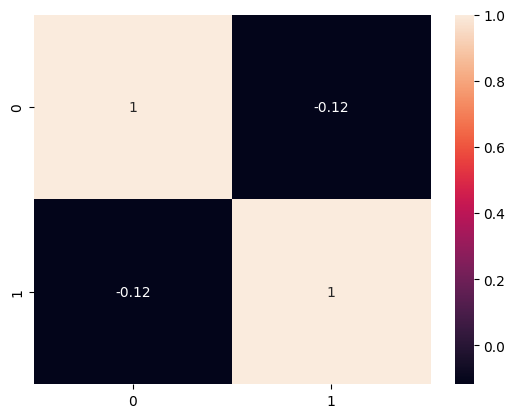

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('iris.csv')
col1 = df['sepal_length']
col2 = df['sepal_width']

print(df.head())

plt.scatter(col1, col2)
plt.show()
print("Pearson correlation coefficient:\n", np.corrcoef(col1, col2)[0, 1])
print("Covariance matrix:\n", np.cov(col1, col2))

sns.heatmap(np.corrcoef(col1, col2), annot=True, cbar=True)
plt.show()

# Exp3

   sepal_length  sepal_width  petal_length  petal_width variety
0           5.1          3.5           1.4          0.2  Setosa
1           4.9          3.0           1.4          0.2  Setosa
2           4.7          3.2           1.3          0.2  Setosa
3           4.6          3.1           1.5          0.2  Setosa
4           5.0          3.6           1.4          0.2  Setosa
Original dfset shape: (150, 4)
Reduced dfset shape: (150, 2)


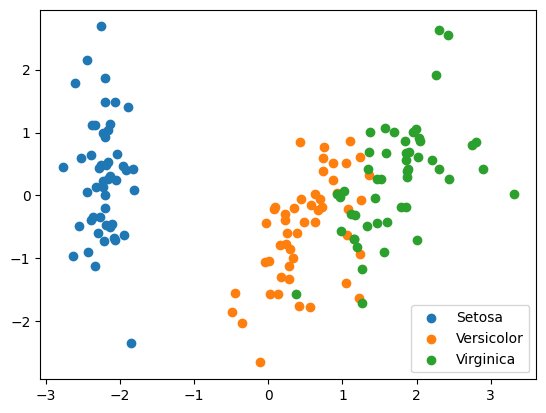

Explained variance ratio: [0.72962445 0.22850762]


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('iris.csv')
print(df.head())

X = StandardScaler().fit_transform(df.iloc[:, :-1])
y = df.iloc[:, -1]

pca = PCA(n_components=2)
X = pca.fit_transform(X)

print("Original dfset shape:", df.iloc[:, :-1].shape)
print("Reduced dfset shape:", X.shape)

for target in np.unique(y):
    plt.scatter(X[y == target, 0], X[y == target, 1], label=target)
plt.legend()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

# Exp4

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv('iris.csv')
print(df.head())
X = df.iloc[:, :-1]
y = LabelEncoder().fit_transform(df.iloc[:, -1])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

for weight_type in ['uniform', 'distance']:
    print(f"\nKNN with {weight_type} weights:")
    for k in [1, 3, 5]:
        knn = KNeighborsClassifier(n_neighbors=k, weights=weight_type)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)
        print(f"K={k} Accuracy: {knn.score(X_test, y_test):.4f} F1-Score: {f1_score(y_test, y_pred, average='weighted')}")
        print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

   sepal_length  sepal_width  petal_length  petal_width variety
0           5.1          3.5           1.4          0.2  Setosa
1           4.9          3.0           1.4          0.2  Setosa
2           4.7          3.2           1.3          0.2  Setosa
3           4.6          3.1           1.5          0.2  Setosa
4           5.0          3.6           1.4          0.2  Setosa

KNN with uniform weights:
K=1 Accuracy: 0.9111 F1-Score: 0.9111111111111111
Confusion matrix:
 [[15  0  0]
 [ 0 13  3]
 [ 0  1 13]]
K=3 Accuracy: 0.9111 F1-Score: 0.9111111111111111
Confusion matrix:
 [[15  0  0]
 [ 0 13  3]
 [ 0  1 13]]
K=5 Accuracy: 0.9111 F1-Score: 0.9111111111111111
Confusion matrix:
 [[15  0  0]
 [ 0 14  2]
 [ 0  2 12]]

KNN with distance weights:
K=1 Accuracy: 0.9111 F1-Score: 0.9111111111111111
Confusion matrix:
 [[15  0  0]
 [ 0 13  3]
 [ 0  1 13]]
K=3 Accuracy: 0.9111 F1-Score: 0.9111111111111111
Confusion matrix:
 [[15  0  0]
 [ 0 13  3]
 [ 0  1 13]]
K=5 Accuracy: 0.9333 F1-Score: 

# Exp5

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


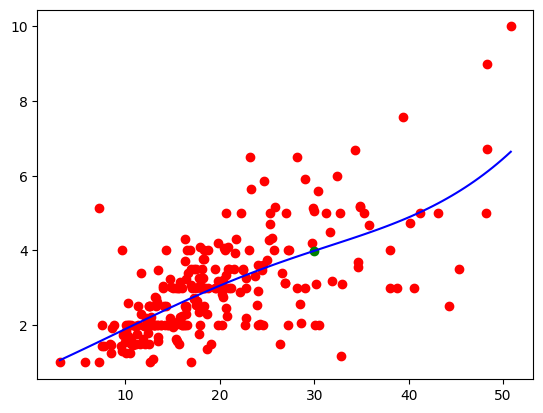

Predicted tip for $30: 3.9909


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('tips.csv')
print(df.head())
X, y = df['total_bill'].values, df['tip'].values
def lwr(x_q, tau=10):
    weights = np.exp(-((X - x_q) ** 2) / (2 * tau ** 2))
    X_b = np.c_[np.ones(len(X)), X]
    W = np.diag(weights)
    beta = np.linalg.pinv(X_b.T @ W @ X_b) @ (X_b.T @ W @ y)
    return np.array([1, x_q]) @ beta

x_range = np.linspace(X.min(), X.max(), 100)
y_pred = [lwr(x) for x in x_range]
plt.scatter(X, y, color='red')
plt.scatter(30, lwr(30), color='green')
plt.plot(x_range, y_pred, color='blue')
plt.show()

print(f"Predicted tip for $30: {lwr(30):.4f}")

# Exp6

## part1

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


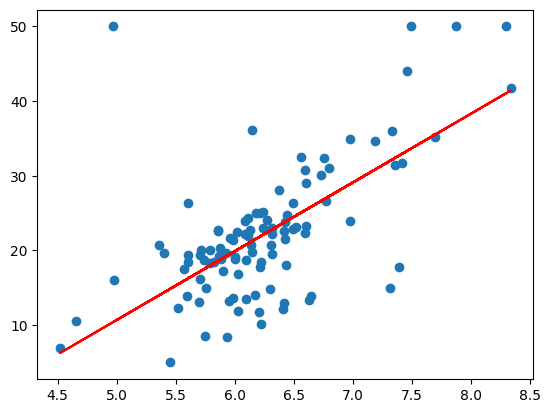

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv('boston-hosing.csv')
print(df.head())
X, y = df[['rm']], df['medv']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = LinearRegression().fit(X_train, y_train)
plt.scatter(X_test, y_test, label='Actual')
plt.plot(X_test, model.predict(X_test), label='Predicted', color='red')
plt.show()

## part2

    mpg  cylinders  displacement  horsepower  weight  acceleration  model-year
0  18.0          8         307.0       130.0    3504          12.0          70
1  15.0          8         350.0       165.0    3693          11.5          70
2  18.0          8         318.0       150.0    3436          11.0          70
3  16.0          8         304.0       150.0    3433          12.0          70
4  17.0          8         302.0       140.0    3449          10.5          70


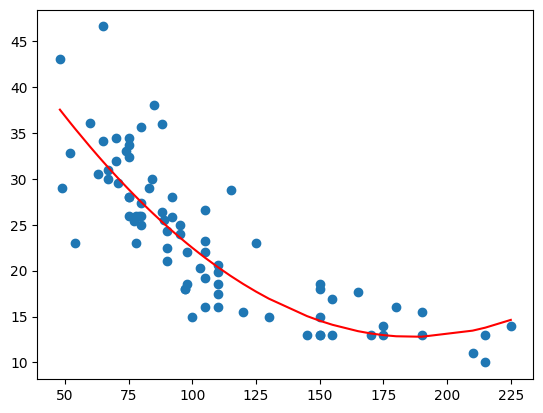

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

df = pd.read_csv('auto-mpg.csv')
print(df.head())
df.replace({'horsepower': {'?': np.nan}}, inplace=True)
df.dropna(subset=['horsepower'], inplace=True)
df['horsepower'] = df['horsepower'].astype(float)
X = df[['horsepower']]
y = df['mpg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
poly = PolynomialFeatures(degree=2)

model = LinearRegression().fit(poly.fit_transform(X_train), y_train)
y_pred = model.predict(poly.transform(X_test))
sorted_index = X_test['horsepower'].argsort()

plt.scatter(X_test, y_test, label='Actual')
plt.plot(X_test.iloc[sorted_index], y_pred[sorted_index], label='Predicted', color='red')
plt.show()

# Exp7

   Survived  Pclass     Sex   Age     Fare
0         0       3    male  22.0   7.2500
1         1       1  female  38.0  71.2833
2         1       3  female  26.0   7.9250
3         1       1  female  35.0  53.1000
4         0       3    male  35.0   8.0500


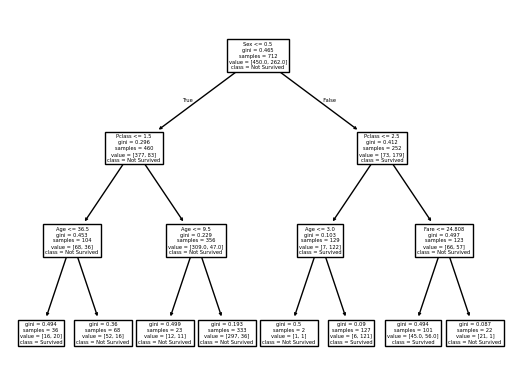

Accuracy: 0.8044692737430168
F1-Score: 0.7586206896551724
Recall: 0.6875
Precision: 0.8461538461538461


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
import matplotlib.pyplot as plt

df = pd.read_csv('titanic.csv')[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]
print(df.head())
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
X, y = df.drop(columns=['Survived']), df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

clf = DecisionTreeClassifier(max_depth=3).fit(X_train, y_train)

plot_tree(clf, feature_names=X.columns, class_names=['Not Survived', 'Survived'])
plt.show()

y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))

# Exp8

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

df = pd.read_csv('iris.csv')
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = GaussianNB().fit(X_train, y_train)
print(f"Accuracy: {accuracy_score(y_test, model.predict(X_test)) * 100:.4f}")

Accuracy: 96.6667


# Exp9

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

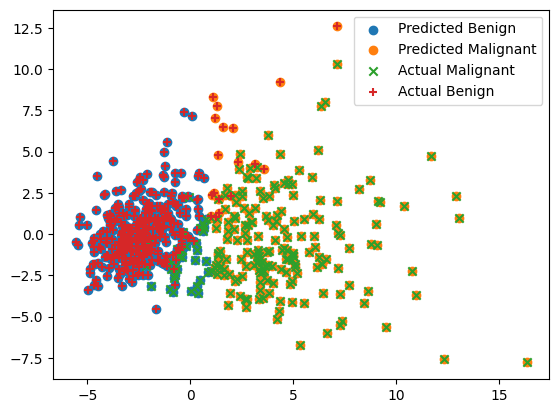

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('breast-cancer.csv')
print(df.head())
diagnosis = df['diagnosis']
X = df.drop(columns=['id', 'diagnosis', 'Unnamed: 32'])

X = StandardScaler().fit_transform(X)
kmeans = KMeans(n_clusters=2).fit(X)
labels = kmeans.labels_

if diagnosis[labels == 0].mode()[0] == 'M':
    cluster_0 = 'Predicted Malignant'
    cluster_1 = 'Predicted Benign'
else:
    cluster_0 = 'Predicted Benign'
    cluster_1 = 'Predicted Malignant'

X = PCA(n_components=2).fit_transform(X)
plt.scatter(X[labels==0, 0], X[labels==0, 1], label=cluster_0,)
plt.scatter(X[labels==1, 0], X[labels==1, 1], label=cluster_1)
plt.scatter(X[diagnosis=='M', 0], X[diagnosis=='M', 1], label='Actual Malignant', marker='x')
plt.scatter(X[diagnosis=='B', 0], X[diagnosis=='B', 1], label='Actual Benign', marker='+')
plt.legend()
plt.show()